In [1]:
import sax
import pandas as pd
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax.typing import ArrayLike
from simphony.libraries import ideal
from simphony.libraries import siepic 
from simphony.classical import ClassicalSim

**Proviamo due configurazioni di accoppiatore direzionale**

In [2]:
siepic.directional_coupler()

{('port_1', 'port_1'): array([0.00333335+0.01235363j]),
 ('port_1', 'port_2'): array([-0.00848899+0.00791805j]),
 ('port_1', 'port_3'): array([-0.83019046+0.28096252j]),
 ('port_1', 'port_4'): array([-0.14791479-0.43977867j]),
 ('port_2', 'port_1'): array([-0.00848899+0.00791805j]),
 ('port_2', 'port_2'): array([0.00333335+0.01235363j]),
 ('port_2', 'port_3'): array([-0.14791479-0.43977867j]),
 ('port_2', 'port_4'): array([-0.83019046+0.28096252j]),
 ('port_3', 'port_1'): array([-0.83019046+0.28096252j]),
 ('port_3', 'port_2'): array([-0.14791479-0.43977867j]),
 ('port_3', 'port_3'): array([0.00333335+0.01235363j]),
 ('port_3', 'port_4'): array([-0.00848899+0.00791805j]),
 ('port_4', 'port_1'): array([-0.14791479-0.43977867j]),
 ('port_4', 'port_2'): array([-0.83019046+0.28096252j]),
 ('port_4', 'port_3'): array([-0.00848899+0.00791805j]),
 ('port_4', 'port_4'): array([0.00333335+0.01235363j])}

In [3]:
siepic.directional_coupler?

Signature:
siepic.directional_coupler(
    wl: Union[float, jax.Array, numpy.ndarray, numpy.bool, numpy.number, bool, int, complex, jax._src.literals.TypedNdArray] = 1.55,
    gap: float = 200,
    coupling_length: float = 10.0,
) -> dict[tuple[str, str], jaxtyping.Complex[Array, '...']]
Docstring:
A directional coupler optimized for TE polarized light at 1550nm.

The directional coupler has 4 ports, labeled as pictured. Its efficiently
splits light that is input from one port into the two outputs on the opposite
side (with a corresponding pi/2 phase shift). Additionally, it efficiently
interferes lights from two adjacent inputs, efficiently splitting the
interfered signal between the two ports on the opposing side.

.. image:: /_static/images/ebeam_bdc_te1550.png
    :alt: ebeam_bdc_te1550.png

Parameters
----------
gap : float, optional
    Coupling gap distance, in nanometers (default 200).
coupling_length : float, optional
    Length of coupler, in microns (default 10).

Notes
----

**Usiamo l'accoppiatore direzionale con gap di 200 nm e lunghezza di accoppiamento di 10µm.**

In [4]:
print(sax.get_ports(siepic.directional_coupler))

('port_1', 'port_2', 'port_3', 'port_4')


In [5]:
tryon, info = sax.circuit(
    netlist={
        "instances": {
            "coupler": "dir_coupler",
            "wg_1": "wg_siepic",
            "wg_2": "wg_ideal",
        },
        "connections": {
            "wg_1,o1": "coupler,port_1",
            "wg_2,o1": "coupler,port_2",
        },
        "ports": {
            "in0": "wg_1,o0",
            "in1": "wg_2,o0",
            "out0": "coupler,port_3",
            "out1": "coupler,port_4",
        },
    },
    models={
        "dir_coupler": siepic.directional_coupler,
        "wg_siepic": siepic.waveguide,
        "wg_ideal": ideal.waveguide,
    }
)

In [6]:
wl = jnp.linspace(1.5, 1.6, 100) ## tra 1.5 e 1.6 μm con 1000 campioni

In [54]:
S = tryon(wl=wl,coupler={"coupling_length": 22.5}, wg_1={"length": 100.0}, wg_2={"length": 100.0})
#print(S)

**DA COLCOLARE CON LE FORMULE**

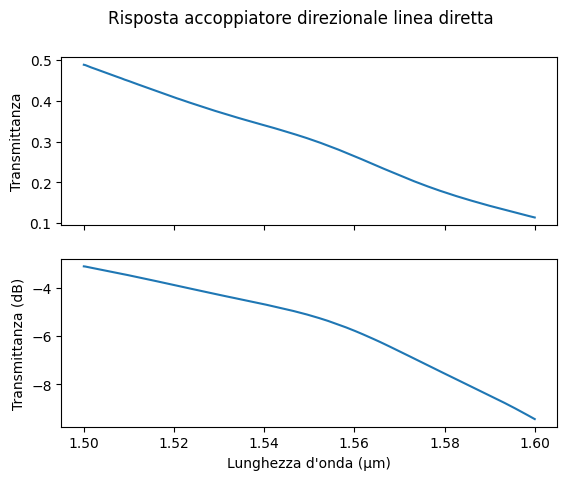

In [55]:
mag1 = jnp.abs(S["out0", "in0"])**2 ##

fig, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(wl, mag1)
axs[0].set_ylabel("Transmittanza")
axs[1].plot(wl, 10*jnp.log10(mag1))
axs[1].set_ylabel("Transmittanza (dB)")
axs[1].set_xlabel("Lunghezza d'onda (µm)")
plt.suptitle("Risposta accoppiatore direzionale linea diretta")
plt.show()

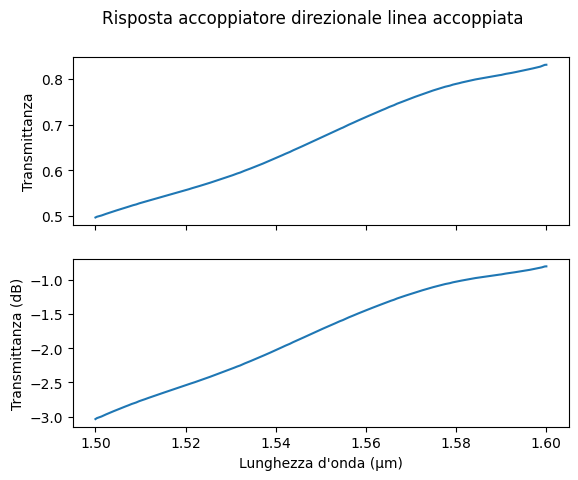

In [56]:
mag2 = jnp.abs(S["out1", "in0"])**2 ##

fig, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(wl, mag2)
axs[0].set_ylabel("Transmittanza")
axs[1].plot(wl, 10*jnp.log10(mag2))
axs[1].set_ylabel("Transmittanza (dB)")
axs[1].set_xlabel("Lunghezza d'onda (µm)")
plt.suptitle("Risposta accoppiatore direzionale linea accoppiata")
plt.show()

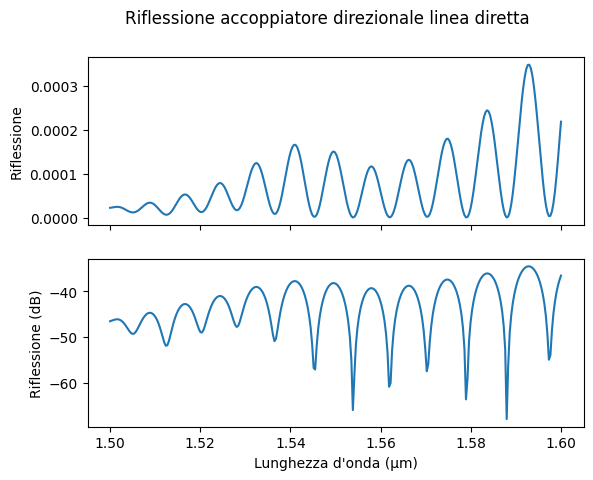

In [57]:
mag3 = jnp.abs(S["in0", "in0"])**2 ##

fig, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(wl, mag3)
axs[0].set_ylabel("Riflessione")
axs[1].plot(wl, 10*jnp.log10(mag3))
axs[1].set_ylabel("Riflessione (dB)")
axs[1].set_xlabel("Lunghezza d'onda (µm)")
plt.suptitle("Riflessione accoppiatore direzionale linea diretta")
plt.show()

In [58]:
## carichiamo la libreria
from simphony.classical import ClassicalSim
## impostiamo le lunghezze d'onda da simulare
wl = jnp.linspace(1.5,1.6,300)
sim = ClassicalSim(ckt=tryon, wl=wl, wg_1={"length":100.0}, wg_2={"length":100.0})
laser = sim.add_laser(ports=["in0"], power=1.0, phase=jnp.pi)
detector1 = sim.add_detector(ports=["out0"])
detector2 = sim.add_detector(ports=["out1"])

In [59]:
result = sim.run()

<Axes: xlabel='Wavelength (um)', ylabel='Power (mW)'>

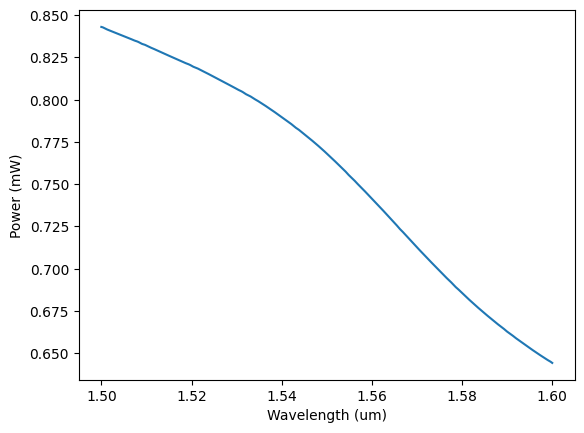

In [60]:
result.detectors["out0"].plot()

<Axes: xlabel='Wavelength (um)', ylabel='Power (mW)'>

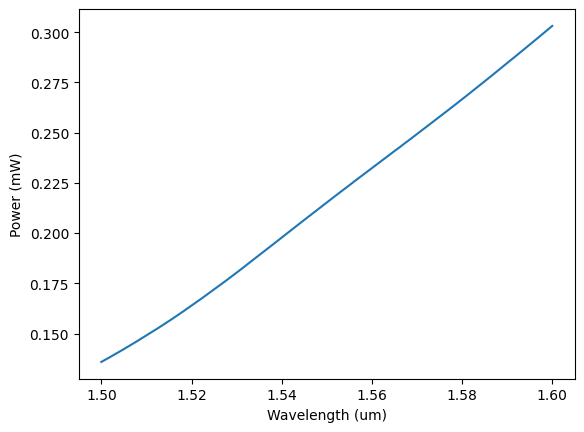

In [61]:
result.detectors["out1"].plot()